In [ ]:
# A. MEsolve, fixed U = 0.005 (for graph 1-3)

import numpy as np
from qutip import *
import os
import itertools

NB = NC = 10

w0 = 1
g = 0.2*w0
U = 0.005*w0
gamma = 0.05*w0

prefactor = [0.01, 0.1, 1, 10]*w0
Delta_values = [i*w0 for i in prefactor]
F_values = [i*w0 for i in prefactor]

end_time = 158  
sigma_wide = 32
sigma_narrow = 10
mu = end_time/2
h0 = 1

b = tensor(destroy(NB), qeye(NC))
c = tensor(qeye(NB), destroy(NC))

tlist = np.linspace(0, end_time, 4001)

HB = b.dag()*b
HC = c.dag()*c
HI = g*(c*b.dag() + c.dag()*b)
HF = c.dag()+c
HU = U*b.dag()*b.dag()*b*b

psi0 = tensor(basis(NB, 0), basis(NC, 0))
c_ops = [np.sqrt(gamma)*c]
T = g*tlist/np.pi
options = Options(nsteps=10000)


def gaussian_kernel(x, sigma, mu):
    return 1/(sigma*np.sqrt(2*np.pi))*np.exp(-((x-mu)**2)/(2*sigma**2))

def step_kernel(x, h0):
    return np.heaviside(x-(end_time/2), h0)


def N_gaussian(sigma, mu):
    return np.trapezoid(gaussian_kernel(tlist, sigma, mu), tlist)

N_step = np.trapezoid(step_kernel(tlist,h0), tlist)


def gaussian_normalized(t, args):
        sigma = args['sigma']
        mu = args['mu']
        F = args['F']
        gaussian = gaussian_kernel(t,sigma,mu)
        return F * gaussian / N_gaussian(sigma, mu)

def step_normalized(t, args):
        h0 = args['h0']
        F = args['F']
        step = step_kernel(t, h0)
        return F * step / N_step


for F, Delta in itertools.product(F_values, Delta_values):

    args = {'mu':mu, 'F': F, 'h0': h0, 'Delta':Delta, 'U':U}

    H_gauss = [HB*Delta, HC*Delta, HI, [HF, gaussian_normalized], HU]
    H_step = [HB*Delta, HC*Delta, HI, [HF, step_normalized], HU]

    result_gauss_wide = mesolve(
        H_gauss, psi0, tlist,
        c_ops = c_ops,
        e_ops = [HB],
        args={**args, 'sigma':sigma_wide},
        options=options
    )

    result_gauss_narrow = mesolve(
        H_gauss, psi0, tlist,
        c_ops = c_ops,
        e_ops = [HB],
        args={**args, 'sigma':sigma_narrow},
        options=options
    )

    result_step = mesolve(
        H_step, psi0, tlist,
        c_ops = c_ops,
        e_ops = [HB],
        args=args,
        options=options
    )

    battery_energy_gauss_wide = result_gauss_wide.expect[0]
    battery_energy_gauss_narrow = result_gauss_narrow.expect[0]
    battery_energy_step = result_step.expect[0]

    folder = f"data/mesolve/fixed_U={U}"
    os.makedirs(folder, exist_ok=True)
    filepath = f"{folder}/F={F}_Delta={Delta}.csv"

    with open(filepath, "w") as f:
        print('times,energy_gauss_wide,energy_gauss_narrow,energy_step', file=f)
        for t, e1, e2, e3 in zip(
            tlist,
            battery_energy_gauss_wide,
            battery_energy_gauss_narrow,
            battery_energy_step
        ):
            print(f'{t},{e1},{e2},{e3}', file=f)

print("Finished running MEsolve for fixed U = ", U)

c:\Users\HP G8\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Finished running MEsolve for fixed U =  0.005


In [ ]:
# B. MEsolve, fixed F = 10, Delta = 0.1 (for graph 4)

import numpy as np
from qutip import *
import os

NB = NC = 10

w0 = 1
g = 0.2*w0
gamma = 0.05*w0

F = 10*w0
Delta = 0.1*w0

U_values = [0, 0.005, 0.05, 0.4, 0.8]

end_time = 158  
sigma_wide = 32
sigma_narrow = 10
mu = end_time/2
h0 = 1

b = tensor(destroy(NB), qeye(NC))
c = tensor(qeye(NB), destroy(NC))

tlist = np.linspace(0, end_time, 4001)

HB = b.dag()*b
HC = c.dag()*c
HI = g*(c*b.dag() + c.dag()*b)
HF = c.dag()+c

psi0 = tensor(basis(NB, 0), basis(NC, 0))
c_ops = [np.sqrt(gamma)*c]
T = g*tlist/np.pi
options = Options(nsteps=10000)

def gaussian_kernel(x, sigma, mu):
    return 1/(sigma*np.sqrt(2*np.pi))*np.exp(-((x-mu)**2)/(2*sigma**2))

def step_kernel(x, h0):
    return np.heaviside(x-(end_time/2), h0)

def N_gaussian(sigma, mu):
    return np.trapezoid(gaussian_kernel(tlist, sigma, mu), tlist)

N_step = np.trapezoid(step_kernel(tlist,h0), tlist)

def gaussian_normalized(t, args):
        sigma = args['sigma']
        mu = args['mu']
        F = args['F']
        gaussian = gaussian_kernel(t,sigma,mu)
        return F * gaussian / N_gaussian(sigma, mu)

def step_normalized(t, args):
        h0 = args['h0']
        F = args['F']
        step = step_kernel(t, h0)
        return F * step / N_step

for U in U_values:

    HU = U*b.dag()*b.dag()*b*b

    args = {'mu':mu, 'F': F, 'h0': h0, 'Delta':Delta, 'U':U}

    H_gauss = [HB*Delta, HC*Delta, HI, [HF, gaussian_normalized], HU]
    H_step = [HB*Delta, HC*Delta, HI, [HF, step_normalized], HU]

    result_gauss_wide = mesolve(
        H_gauss, psi0, tlist,
        c_ops = c_ops,
        e_ops = [HB],
        args={**args, 'sigma':sigma_wide},
        options=options
    )

    result_gauss_narrow = mesolve(
        H_gauss, psi0, tlist,
        c_ops = c_ops,
        e_ops = [HB],
        args={**args, 'sigma':sigma_narrow},
        options=options
    )

    result_step = mesolve(
        H_step, psi0, tlist,
        c_ops = c_ops,
        e_ops = [HB],
        args=args,
        options=options
    )

    battery_energy_gauss_wide = result_gauss_wide.expect[0]
    battery_energy_gauss_narrow = result_gauss_narrow.expect[0]
    battery_energy_step = result_step.expect[0]

    folder = f"data/mesolve/fixed_F={F}_Delta={Delta}"
    os.makedirs(folder, exist_ok=True)
    filepath = f"{folder}/U={U}.csv"

    with open(filepath, "w") as f:
        print('times,energy_gauss_wide,energy_gauss_narrow,energy_step', file=f)
        for t, e1, e2, e3 in zip(
            tlist,
            battery_energy_gauss_wide,
            battery_energy_gauss_narrow,
            battery_energy_step
        ):
            print(f'{t},{e1},{e2},{e3}', file=f)

print("Finished running MEsolve for fixed F and Delta")

Finished running MEsolve for fixed F and Delta


In [ ]:
# C. Tabulate Emax from A cellcode (fixed U = 0.005)

import numpy as np
import os
import itertools

w0 = 1

U = 0.005*w0

prefactor = [0.01, 0.1, 1, 10]*w0
Delta_values = [i*w0 for i in prefactor]
F_values = [i*w0 for i in prefactor]

source_folder = f"data/mesolve/fixed_U={U}"
output_folder = "data/emax"
os.makedirs(output_folder, exist_ok=True)

rows = []

for F, Delta in itertools.product(F_values, Delta_values):

    filepath = f"{source_folder}/F={F}_Delta={Delta}.csv"

    data = np.loadtxt(filepath, delimiter=",", skiprows=1)

    Ewide   = data[:,1]
    Enarrow = data[:,2]
    Estep   = data[:,3]

    Emax_wide   = np.max(Ewide)
    Emax_narrow = np.max(Enarrow)
    Emax_step   = np.max(Estep)

    rows.append([
        Emax_wide, 0,
        Emax_narrow, 0,
        Emax_step, 0,
        Delta, F, U
    ])

emaxtabulation_path = f"{output_folder}/emaxtabulation_fixedU.csv"

with open(emaxtabulation_path, "w") as f:
    print("Ewide,,Enarrow,,Estep,,Delta,F,U", file=f)
    for row in rows:
        print(",".join(map(str, row)), file=f)

print("Emax tabulation finished →", emaxtabulation_path)

Emax tabulation finished → data/emax/emaxtabulation.csv


In [19]:
# D. Tabulate Emax from B cellcode (fixed F = 10, Delta = 0.1)

import numpy as np
import os

w0 = 1
g = 0.2 * w0

F = 10 * w0
Delta = 0.1 * w0

U_values = [0, 0.005, 0.05, 0.4, 0.8]

source_folder = f"data/mesolve/fixed_F={F}_Delta={Delta}"
output_folder = "data/emax"
os.makedirs(output_folder, exist_ok=True)

rows = []

for U in U_values:
    filepath = f"{source_folder}/U={U}.csv"

    data = np.loadtxt(filepath, delimiter=",", skiprows=1)

    time = data[:, 0] * g / np.pi
    Ewide   = data[:, 1]
    Enarrow = data[:, 2]
    Estep   = data[:, 3]

    Emax_wide   = np.max(Ewide)
    Emax_narrow = np.max(Enarrow)
    Emax_step   = np.max(Estep)

    rows.append([
        Emax_wide, 0,
        Emax_narrow, 0,
        Emax_step, 0,
        Delta, F, U
    ])

emaxtabulation_path = f"{output_folder}/emaxtabulation_fixedFandDelta.csv"

with open(emaxtabulation_path, "w") as f:
    print("Ewide,,Enarrow,,Estep,,Delta,F,U", file=f)
    for row in rows:
        print(",".join(map(str, row)), file=f)

print("Emax tabulation finished →", emaxtabulation_path)

Emax tabulation finished → data/emax/emaxtabulation_fixedFandDelta.csv


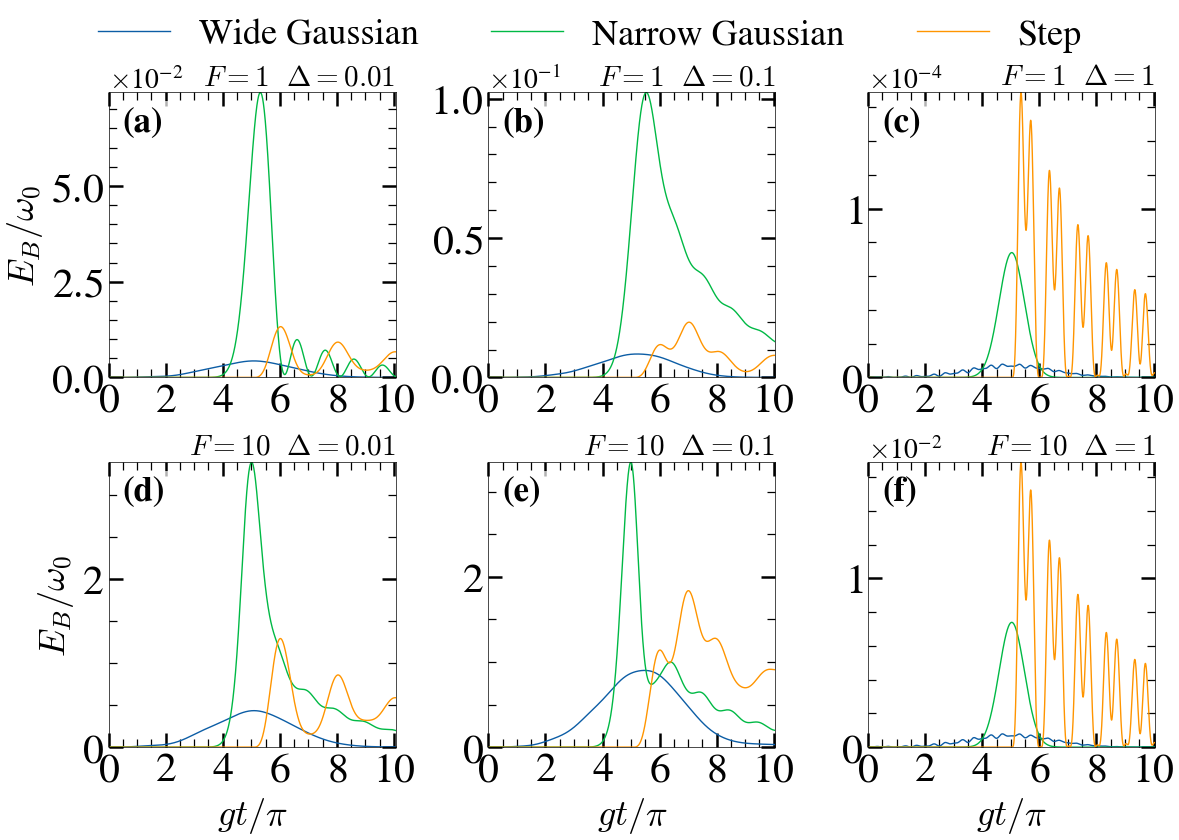

In [ ]:
# E. Graph 1 (E vs t)

import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import string
import itertools

plt.style.use(['science', 'no-latex'])

graph_row = 2
graph_column = 3

w0 = 1
g = 0.2 * w0
U = 0.005 * w0

Delta_values = [0.01, 0.1, 1] * w0
F_values = [1, 10] * w0

fig, axes = plt.subplots(graph_row, graph_column, figsize=(12, 8))
axes = axes.flatten()

folder = f"data/mesolve/fixed_U={U}"

for i, (F, Delta) in enumerate(itertools.product(F_values, Delta_values)):
    ax = axes[i]

    filepath = f"{folder}/F={F}_Delta={Delta}.csv"
    data = np.loadtxt(filepath, delimiter=",", skiprows=1)

    time = data[:, 0]
    energy_gauss_wide   = data[:, 1]
    energy_gauss_narrow = data[:, 2]
    energy_step         = data[:, 3]

    ax.plot(g * time / np.pi, energy_gauss_wide,   label="Wide Gaussian")
    ax.plot(g * time / np.pi, energy_gauss_narrow, label="Narrow Gaussian")
    ax.plot(g * time / np.pi, energy_step,         label="Step")

    ax.set_title(f"$F={F}~~ \\Delta={Delta}$", fontsize=21, loc="right")
    ax.margins(0, 0)

    ax.set_xticks(np.arange(0, 12, 2))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(20)
    ax.tick_params(axis="both", which="major", labelsize=30, length=10, width=1.8)
    ax.tick_params(which="minor", length=6, width=0.9)

    ax.text(
        0.05, 0.95,
        f"({string.ascii_lowercase[i]})",
        transform=ax.transAxes,
        fontsize=25,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
    )

    if i % graph_column == 0:
        ax.set_ylabel(r"$E_B / \omega_0$", fontsize=26)

    if i >= graph_column * (graph_row - 1):
        ax.set_xlabel(r"$gt/\pi$", fontsize=26)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.08),
    fontsize=26,
)

plt.tight_layout()
plt.savefig("fig1-Evst.pdf", bbox_inches="tight")
plt.show()

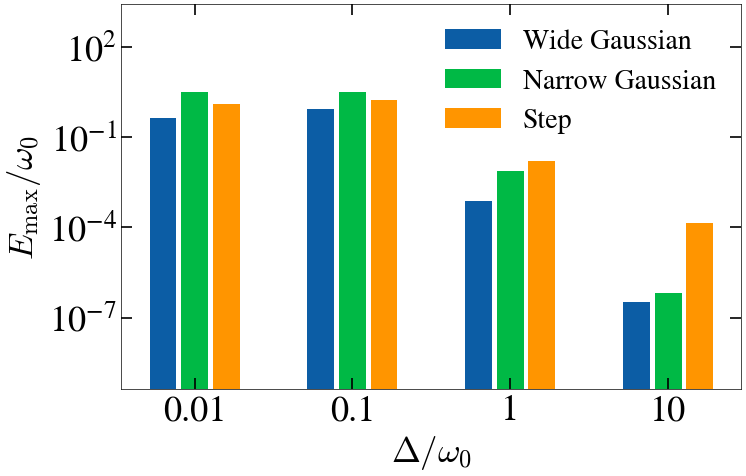

In [ ]:
# F. Graph 2 (Emax vs Delta)

import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullLocator, NullFormatter, FuncFormatter

plt.style.use(['science', 'no-latex'])

w0 = 1
U_target = 0.005*w0
F_target = 10*w0

group_width = 0.6
gap_frac = 0.15

data = np.loadtxt("data/emax/emaxtabulation_fixedU.csv", delimiter=",", skiprows=1)

Ewide   = data[:, 0]
Enarrow = data[:, 2]
Estep   = data[:, 4]
Delta   = data[:, 6]
F       = data[:, 7]
U       = data[:, 8]

mask = (U == U_target) & (F == F_target)

Delta   = Delta[mask]
Ewide   = Ewide[mask]
Enarrow = Enarrow[mask]
Estep   = Estep[mask]

idx = np.argsort(Delta)
Delta   = Delta[idx]
Ewide   = Ewide[idx]
Enarrow = Enarrow[idx]
Estep   = Estep[idx]

all_E = np.concatenate([Ewide, Enarrow, Estep])
ymin = all_E.min() / 800
ymax = all_E.max() * 800

fig, ax = plt.subplots(figsize=(8,5))

x = np.log10(Delta)
bar_width = group_width / 3 * (1 - gap_frac)
offset = group_width / 3

def draw_bar(xc, h, dx, label):
    xl = xc + dx - bar_width/2
    xr = xc + dx + bar_width/2
    left = 10**xl
    width = 10**xr - 10**xl
    ax.bar(left, h, width=width, align='edge', label=label)

draw_bar(x, Ewide,   -offset, 'Wide Gaussian')
draw_bar(x, Enarrow,  0.0,    'Narrow Gaussian')
draw_bar(x, Estep,   +offset, 'Step')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2,10)))
ax.yaxis.set_minor_formatter(NullFormatter())

ax.xaxis.set_minor_locator(NullLocator())

def delta_formatter(val, pos):
    return f"{val:g}"

ax.xaxis.set_major_formatter(FuncFormatter(delta_formatter))

ax.tick_params(axis='both', which='major', labelsize=26, length=8, width=1.2)
ax.tick_params(axis='y', which='minor', length=4, width=0.8)

ax.set_xlabel(r'$\Delta / \omega_0$', fontsize=25)
ax.set_ylabel(r'$E_{\max} / \omega_0$', fontsize=25)

ax.legend(fontsize=20)

plt.savefig("fig2-EmaxvsDelta.pdf", bbox_inches='tight')
plt.show()

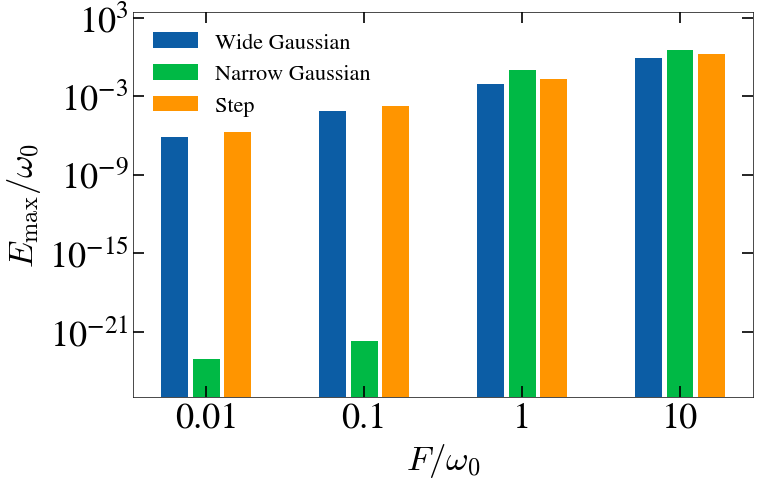

In [ ]:
# G. Graph 3 (Emax vs F)

import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullLocator, NullFormatter, FuncFormatter

plt.style.use(['science', 'no-latex'])

w0 = 1
U_target     = 0.005*w0
Delta_target = 0.1*w0

group_width = 0.6
gap_frac = 0.15

data = np.loadtxt("data/emax/emaxtabulation_fixedU.csv", delimiter=",", skiprows=1)

Ewide   = data[:, 0]
Enarrow = data[:, 2]
Estep   = data[:, 4]
Delta   = data[:, 6]
F       = data[:, 7]
U       = data[:, 8]

mask = (U == U_target) & (Delta == Delta_target) & (F > 0)

F       = F[mask]
Ewide   = Ewide[mask]
Enarrow = Enarrow[mask]
Estep   = Estep[mask]

idx = np.argsort(F)
F       = F[idx]
Ewide   = Ewide[idx]
Enarrow = Enarrow[idx]
Estep   = Estep[idx]

all_E = np.concatenate([Ewide, Enarrow, Estep])
ymin = all_E.min() / 800
ymax = all_E.max() * 800

fig, ax = plt.subplots(figsize=(8,5))

x = np.log10(F)
bar_width = group_width / 3 * (1 - gap_frac)
offset = group_width / 3

def draw_bar(xc, h, dx, label):
    xl = xc + dx - bar_width/2
    xr = xc + dx + bar_width/2
    left = 10**xl
    width = 10**xr - 10**xl
    ax.bar(left, h, width=width, align='edge', label=label)

draw_bar(x, Ewide,   -offset, 'Wide Gaussian')
draw_bar(x, Enarrow,  0.0,    'Narrow Gaussian')
draw_bar(x, Estep,   +offset, 'Step')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2,10)))
ax.yaxis.set_minor_formatter(NullFormatter())

ax.xaxis.set_minor_locator(NullLocator())

def F_formatter(val, pos):
    return f"{val:g}"

ax.xaxis.set_major_formatter(FuncFormatter(F_formatter))

ax.tick_params(axis='both', which='major', labelsize=26, length=8, width=1.2)
ax.tick_params(axis='y', which='minor', length=4, width=0.8)

ax.set_xlabel(r'$F/\omega_0$', fontsize=25)
ax.set_ylabel(r'$E_{\max} / \omega_0$', fontsize=25)

ax.legend(fontsize=16)

plt.savefig("fig3-EmaxvsF.pdf", bbox_inches='tight')
plt.show()

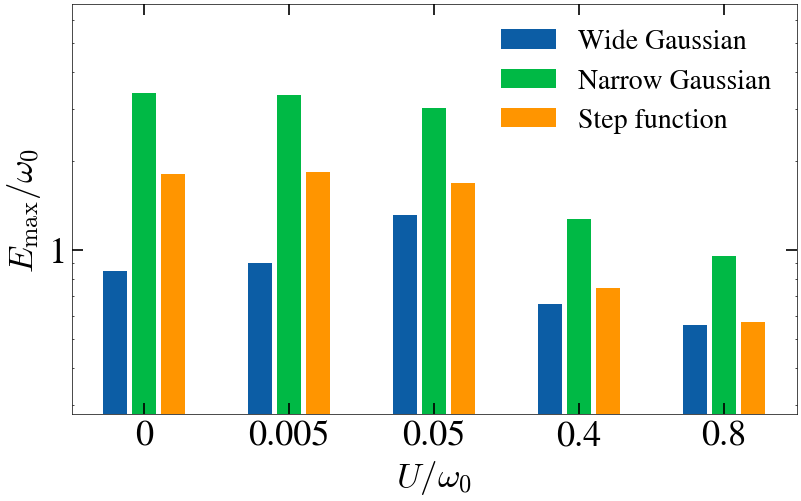

In [ ]:
# H. Graph 4 (Emax vs U)

import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.ticker import LogLocator, FuncFormatter, NullLocator

plt.style.use(['science', 'no-latex'])

F_target     = 10
Delta_target = 0.1

group_width = 0.6
gap_frac    = 0.15

data = np.loadtxt(
    "data/emax/emaxtabulation_fixedFandDelta.csv",
    delimiter=",",
    skiprows=1
)

Ewide   = data[:, 0]
Enarrow = data[:, 2]
Estep   = data[:, 4]
Delta   = data[:, 6]
F       = data[:, 7]
U       = data[:, 8]

mask = (F == F_target) & (Delta == Delta_target)

U       = U[mask]
Ewide   = Ewide[mask]
Enarrow = Enarrow[mask]
Estep   = Estep[mask]

idx = np.argsort(U)
U       = U[idx]
Ewide   = Ewide[idx]
Enarrow = Enarrow[idx]
Estep   = Estep[idx]

x = np.arange(len(U))
bar_width = group_width / 3 * (1 - gap_frac)
offset    = group_width / 3

all_E = np.concatenate([Ewide, Enarrow, Estep])
ymin = all_E.min() / 2
ymax = all_E.max() * 2

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax.bar(x - offset, Ewide,   width=bar_width, label="Wide Gaussian")
ax.bar(x,          Enarrow, width=bar_width, label="Narrow Gaussian")
ax.bar(x + offset, Estep,   width=bar_width, label="Step function")

ax.set_yscale("log")
ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_locator(LogLocator(base=10))

def plain_log_formatter(val, pos):
    if val >= 1:
        return f"{val:.0f}"
    else:
        return f"{val:g}"

ax.yaxis.set_major_formatter(FuncFormatter(plain_log_formatter))

ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_xticks(x)
ax.set_xticklabels([f"{u:g}" for u in U])
ax.xaxis.set_minor_locator(NullLocator())

ax.tick_params(axis="both", which="major",
               labelsize=26, length=8, width=1.2)

ax.set_xlabel(r"$U/\omega_0$", fontsize=25)
ax.set_ylabel(r"$E_{\max} / \omega_0$", fontsize=25)

ax.legend(fontsize=20)
plt.savefig("fig4-EmaxvsU.pdf", bbox_inches='tight')
plt.show()